In [21]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from zonolayer import Zonolayer

In [22]:
class CentreNet(nn.Module):
    """Simple neural network for 1D regression."""
    def __init__(self, input_dim=1, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


def nonlinear_data(n):
    n_samples = n
    x = np.random.rand(n_samples)
    w = np.random.normal(0, 0.025, n_samples)
    y = 0.3 * (15 * x * np.exp(-3 * x) + w * x)
    y_radius = (1/160) * (np.abs(x - 2) + 0.5)
    y_lower = y - y_radius
    y_upper = y + y_radius

    x_grid = np.linspace(0, 10, n_samples)

    return n_samples, x, y, y_lower, y_upper, x_grid


n, x, y, y_lower, y_upper, x_grid = nonlinear_data(1240)

# Tensor conversion for PyTorch
y_lb_t = torch.tensor(y_lower, dtype=torch.float32).unsqueeze(1)
y_ub_t = torch.tensor(y_upper, dtype=torch.float32).unsqueeze(1)
x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(1)

# 3. Train the centre network on the midpoints of the intervals to fit a regression line


def train_centre(x_t, y_lb_t, y_ub_t, epochs=500, lr=1e-3, batch_size=64, print_every=20):
    y_mid = 0.5 * (y_lb_t + y_ub_t)  # midpoints

    centre_net = CentreNet(input_dim=x_t.shape[1])
    optimizer = torch.optim.Adam(centre_net.parameters(), lr=lr)
    criterion = nn.MSELoss()

    n_samples = x_t.shape[0]

    for epoch in range(epochs):
        perm = torch.randperm(n_samples)
        epoch_loss = 0.0
        for i in range(0, n_samples, batch_size):
            idx = perm[i:i+batch_size]
            xb = x_t[idx]
            yb = y_mid[idx]

            pred = centre_net(xb)
            loss = criterion(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * len(xb)

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}: MSE = {epoch_loss / n_samples:.6f}")

    return centre_net


centre_net = train_centre(x_t, y_lb_t, y_ub_t)

Epoch 20: MSE = 0.012643
Epoch 40: MSE = 0.003989
Epoch 60: MSE = 0.000305
Epoch 80: MSE = 0.000096
Epoch 100: MSE = 0.000054
Epoch 120: MSE = 0.000036
Epoch 140: MSE = 0.000029
Epoch 160: MSE = 0.000029
Epoch 180: MSE = 0.000025
Epoch 200: MSE = 0.000024
Epoch 220: MSE = 0.000023
Epoch 240: MSE = 0.000024
Epoch 260: MSE = 0.000022
Epoch 280: MSE = 0.000023
Epoch 300: MSE = 0.000022
Epoch 320: MSE = 0.000022
Epoch 340: MSE = 0.000022
Epoch 360: MSE = 0.000022
Epoch 380: MSE = 0.000022
Epoch 400: MSE = 0.000021
Epoch 420: MSE = 0.000021
Epoch 440: MSE = 0.000022
Epoch 460: MSE = 0.000021
Epoch 480: MSE = 0.000020
Epoch 500: MSE = 0.000022


In [23]:
test_set = torch.linspace(x_t.min(), x_t.max(), n).unsqueeze(1)

zl = Zonolayer(centre_net)
results = zl.compute(x_t, test_set, y_lower, y_upper, ipm=True)

# Unpack results
y_lower_pred = results["y_lower_pred"]
y_upper_pred = results["y_upper_pred"]
centre_pred = results["pred_centre"]
ipm_lower = results["y_lower_ipm"]
ipm_upper = results["y_upper_ipm"]

     pcost       dcost       gap    pres   dres   k/t
 0:  2.2204e-16  3.9710e-17  2e+00  2e+00  4e-16  1e+00
 1:  6.8717e-04  6.6674e-04  8e-02  9e-02  3e-16  4e-02
 2:  2.7346e-02  1.6527e-02  5e-02  4e-02  5e-16  6e-03
 3:  3.4639e-02  2.4561e-02  3e-02  3e-02  4e-16  2e-03
 4:  3.6852e-02  2.6413e-02  4e-02  3e-02  9e-16  2e-03
 5:  3.7212e-02  2.6819e-02  4e-02  3e-02  9e-16  1e-03
 6:  4.2345e-02  3.3970e-02  3e-02  2e-02  2e-15  8e-04
 7:  5.2896e-02  5.1320e-02  5e-03  4e-03  2e-15  7e-05
 8:  5.4283e-02  5.3818e-02  2e-03  1e-03  7e-16  1e-05
 9:  5.5054e-02  5.5039e-02  5e-05  4e-05  3e-15  2e-07
10:  5.5083e-02  5.5083e-02  5e-07  4e-07  2e-15  2e-09
11:  5.5084e-02  5.5084e-02  5e-09  4e-09  9e-15  2e-11
Optimal solution found.


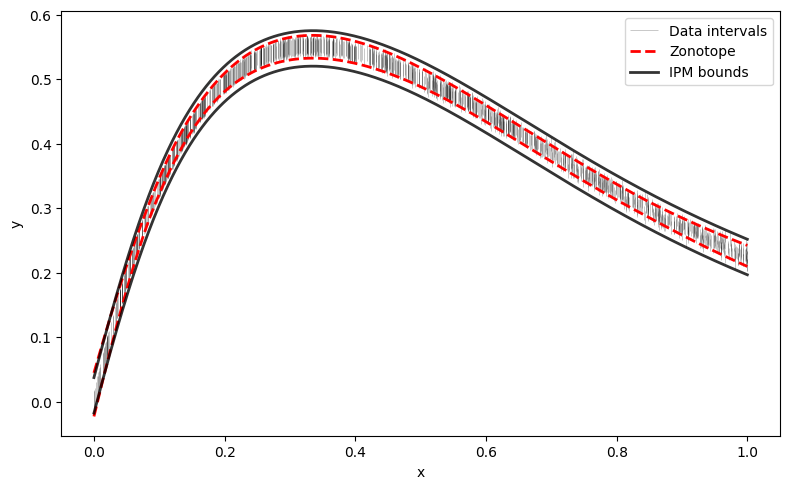

In [24]:
x_plot = np.linspace(x_t.min(), x_t.max(), n)

plt.figure(figsize=(8, 5))

x_sorted, idx = torch.sort(x_t, dim=0)
y_lb_sorted = y_lb_t[idx]
y_ub_sorted = y_ub_t[idx]

plt.vlines(x_sorted.numpy().flatten(),
           y_lb_sorted.numpy().flatten(),
           y_ub_sorted.numpy().flatten(),
           color='black', alpha=.3, linewidth=0.5,
           label='Data intervals')

# Plot NN prediction
#plt.plot(x_plot.numpy(), centre_pred, color='green', lw=1.5, label='NN prediction', zorder=5)

plt.plot(x_plot.numpy(), y_lower_pred, 'r--', lw=2, label='Zonotope')
plt.plot(x_plot.numpy(), y_upper_pred, 'r--', lw=2, label='__nolegend__')

#plt.fill_between(x_plot.numpy(), y_lower_pred, y_upper_pred, color='red', alpha=0.3, label='Zonotope expectation band')

plt.plot(x_plot.numpy(), ipm_lower, 'black', lw=2, label='IPM bounds', alpha=0.8)
plt.plot(x_plot.numpy(), ipm_upper, 'black', lw=2, label='__nolegend__', alpha=0.8)


plt.legend()
plt.title("")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.savefig("UnivariateNonLinear.png", bbox_inches="tight")
plt.show()